In [ ]:
from google.colab import drive, files
drive.mount('/content/gdrive/')

import os
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis"
os.chdir(PROJECT_FOLDER)
print("Current dir: ", os.getcwd())

Mounted at /content/gdrive/
Current dir:  /content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis


In [ ]:
import pandas as pd
data = pd.read_csv("AMZN_VADER_SCORE_READY_FOR_TRAINING.csv")
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,neg,neu,pos,compound
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.000,0.923,0.077,0.8850
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.067,0.889,0.044,-0.7430
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.065,0.829,0.106,0.8449
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",0.017,0.855,0.128,0.9501
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",0.014,0.914,0.072,0.9008


In [ ]:
amzn_adj_and_compound = data[['Close','compound']]
amzn_adj_and_compound.head()

,Close,compound
0,159.524506,0.8850
1,161.195496,-0.7430
2,157.597000,0.8449
3,158.073502,0.9501
4,161.145004,0.9008


In [ ]:
amzn_adj_and_compound_array = amzn_adj_and_compound.values
print(amzn_adj_and_compound_array)

[[159.52450562   0.885     ]
 [161.19549561  -0.743     ]
 [157.59700012   0.8449    ]
 ...
 [188.71000671  -0.2732    ]
 [192.08000183   0.8422    ]
 [193.05999756  -0.9246    ]]


In [ ]:
amzn_comp_len = int(len(amzn_adj_and_compound_array) *0.8)
print(amzn_comp_len)

785


In [ ]:
training_data = amzn_adj_and_compound_array[0:amzn_comp_len]
print(training_data)
print('\n')
print("\n")
print(type(training_data))


[[159.52450562   0.885     ]
 [161.19549561  -0.743     ]
 [157.59700012   0.8449    ]
 ...
 [180.83000183   0.7845    ]
 [179.8500061    0.3818    ]
 [182.5          0.8885    ]]




<class 'numpy.ndarray'>


In [ ]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956  0.88567694]
 [ 0.34329829 -0.75124428]
 [ 0.28239973  0.8453572 ]
 ...
 [ 0.67557966  0.78462621]
 [ 0.65899486  0.37971947]
 [ 0.7038416   0.88919612]]


(785, 2)


In [ ]:
test = amzn_adj_and_compound_array[amzn_comp_len :]
print(test.shape)

(197, 2)


In [ ]:
days = 30

In [ ]:
test_inputs = amzn_adj_and_compound_array[len(amzn_adj_and_compound_array) - len(test) -days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 2)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (227, 2)
Test inputs with a reshape : (227, 2)
Test inputs after transformed : (227, 2)


In [ ]:
X_train = []
y_train = []

for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))


These values are smaller than the 30 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(755, 30, 2)
(755, 1)


In [ ]:
X_test = []
y_test = amzn_adj_and_compound_array[amzn_comp_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],2))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(755, 30, 2)
755
30


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],2))
print(X_test.shape)

(197, 30, 2)
(197, 30, 2)


In [ ]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, Activation, Dense
model1 = Sequential()
model1.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 2), activation='tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units = 100, activation='tanh'))
model1.add(Dropout(0.2))
model1.add(Dense(units=1))
model1.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 30, 100)        │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 30, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 30, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,501 (1.08 MB)

 Trainable params: 282,501 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
seed = 412
np.random.seed(412)
tf.random.set_seed(seed)
history1 = model1.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1203 - mae: 0.2632
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0307 - mae: 0.1357
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0247 - mae: 0.1242
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0197 - mae: 0.1093
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0185 - mae: 0.1069
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0169 - mae: 0.1015
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0165 - mae: 0.0986
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0148 - mae: 0.0948
Epoch 9/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0143 - mae: 0.0923
Epoch 10/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0141 - mae: 0.0921
Epoch 11/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0133 - mae: 0.0911
Epoch 12/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0123 - mae: 0.0861
Epoch 13/300
24/24 ━━━━━━

Text(0, 0.5, 'MAE')

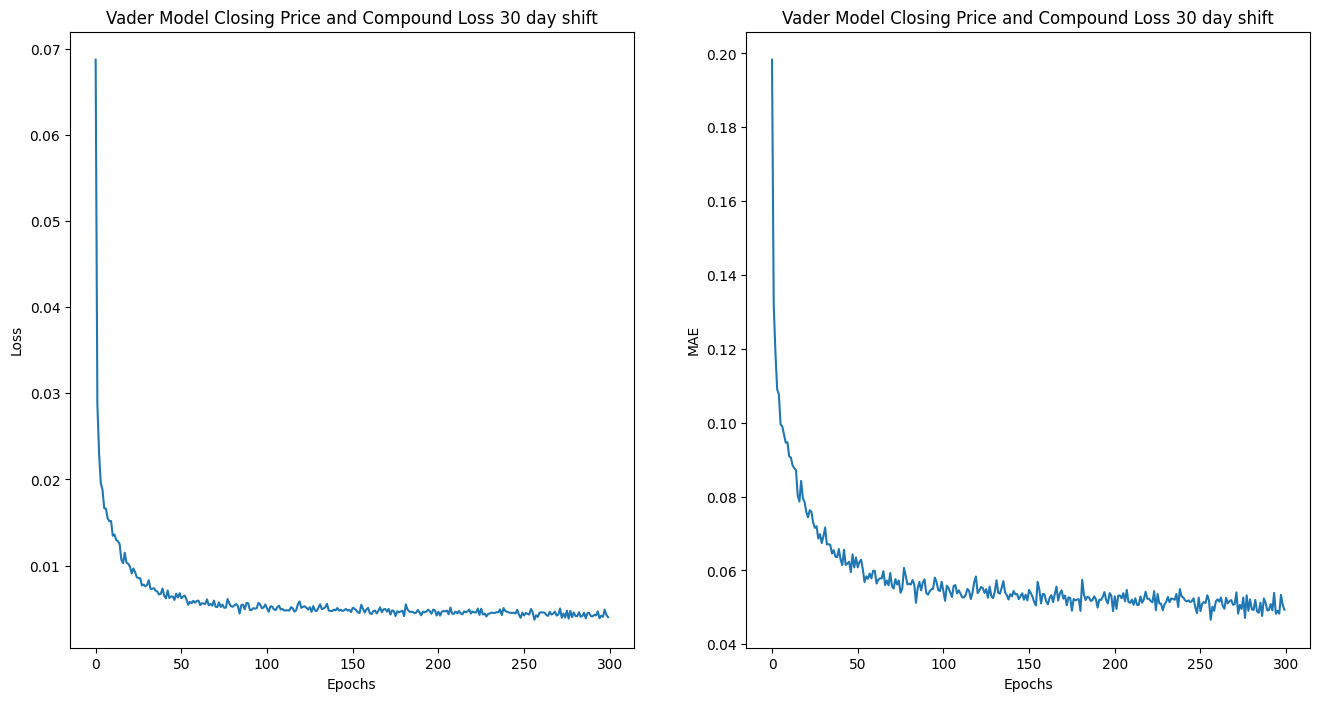

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and Compound Loss 30 day shift")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history1.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price and Compound Loss 30 day shift")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
dates = data['Date']
dates.head()

,Date
0,2021-05-10
1,2021-05-11
2,2021-05-12
3,2021-05-13
4,2021-05-14


In [ ]:
predictions = model1.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 1))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
rmse1 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse1)

9.740886400528995


<ipython-input-32-14828e6653fa>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Date'] = dates[:amzn_comp_len]
<ipython-input-32-14828e6653fa>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['Date'] = dates[amzn_comp_len:]
<ipython-input-32-14828e6653fa>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

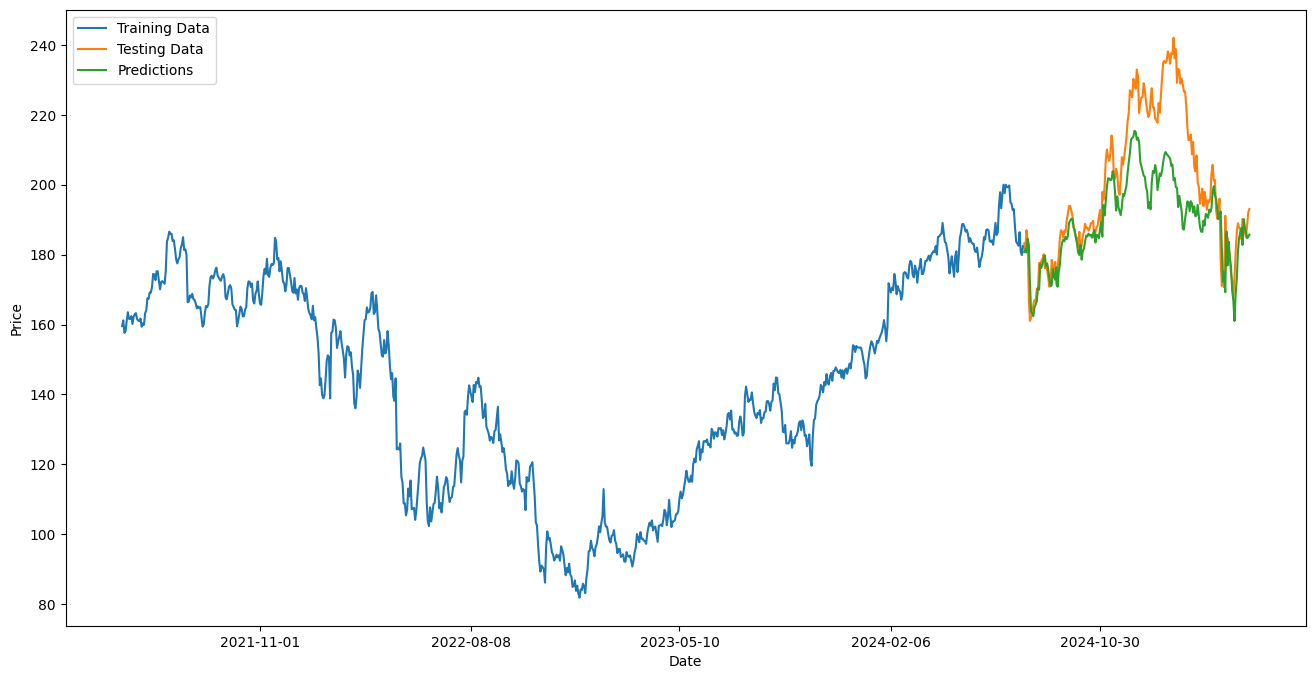

In [ ]:
import matplotlib.dates as mdates
train = amzn_adj_and_compound[:amzn_comp_len]
train['Date'] = dates[:amzn_comp_len]
testing = amzn_adj_and_compound[amzn_comp_len:]
testing['Date'] = dates[amzn_comp_len:]
testing['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train['Date'],train['Close'], label = "Training Data")
plt.plot(testing['Date'],testing['Close'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# **Model 2 with Closing, positive and negative**

In [ ]:
amzn_adj_scores = data[['Close','neg','pos']]
amzn_adj_scores.head()

,Close,neg,pos
0,159.524506,0.000,0.077
1,161.195496,0.067,0.044
2,157.597000,0.065,0.106
3,158.073502,0.017,0.128
4,161.145004,0.014,0.072


In [ ]:
amzn_adj_scores_array = amzn_adj_scores.values
print(amzn_adj_scores_array)

[[1.59524506e+02 0.00000000e+00 7.70000000e-02]
 [1.61195496e+02 6.70000000e-02 4.40000000e-02]
 [1.57597000e+02 6.50000000e-02 1.06000000e-01]
 ...
 [1.88710007e+02 3.60000000e-02 3.30000000e-02]
 [1.92080002e+02 2.00000000e-02 7.80000000e-02]
 [1.93059998e+02 8.10000000e-02 3.50000000e-02]]


In [ ]:
amzn_len = int(len(amzn_adj_scores_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_adj_scores_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[1.59524506e+02 0.00000000e+00 7.70000000e-02]
 [1.61195496e+02 6.70000000e-02 4.40000000e-02]
 [1.57597000e+02 6.50000000e-02 1.06000000e-01]
 ...
 [1.80830002e+02 3.70000000e-02 7.20000000e-02]
 [1.79850006e+02 3.90000000e-02 6.00000000e-02]
 [1.82500000e+02 7.00000000e-03 5.70000000e-02]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[0.65750978 0.         0.1974359 ]
 [0.67164914 0.26070039 0.11282051]
 [0.64119987 0.25291829 0.27179487]
 ...
 [0.83778983 0.14396887 0.18461538]
 [0.82949743 0.15175097 0.15384615]
 [0.8519208  0.02723735 0.14615385]]


(785, 3)


In [ ]:
test = amzn_adj_scores_array[amzn_len:]
print(test.shape)

(197, 3)


In [ ]:
test_inputs = amzn_adj_scores_array[len(amzn_adj_scores_array) - len(test) -days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 3)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (227, 3)
Test inputs with a reshape : (227, 3)
Test inputs after transformed : (227, 3)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 30 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(755, 30, 3)
(755, 1)


In [ ]:
X_test = []
y_test = amzn_adj_scores_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],3))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(755, 30, 3)
755
30


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],3))
print(X_test.shape)

(197, 30, 3)
(197, 30, 3)


In [ ]:
model2 = Sequential()
model2.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 3), activation='tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units = 100, activation='tanh'))
model2.add(Dropout(0.2))
model2.add(Dense(units=1))
model2.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 30, 100)        │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 30, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 30, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,901 (1.08 MB)

 Trainable params: 282,901 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = model2.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0859 - mae: 0.2186
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0101 - mae: 0.0769
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0093 - mae: 0.0743
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0081 - mae: 0.0690
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0077 - mae: 0.0681
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0100 - mae: 0.0786
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0082 - mae: 0.0691
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0068 - mae: 0.0639
Epoch 9/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0061 - mae: 0.0600
Epoch 10/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0058 - mae: 0.0591
Epoch 11/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0058 - mae: 0.0586
Epoch 12/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0051 - mae: 0.0555
Epoch 13/300
24/24 ━━━━━━

Text(0, 0.5, 'MAE')

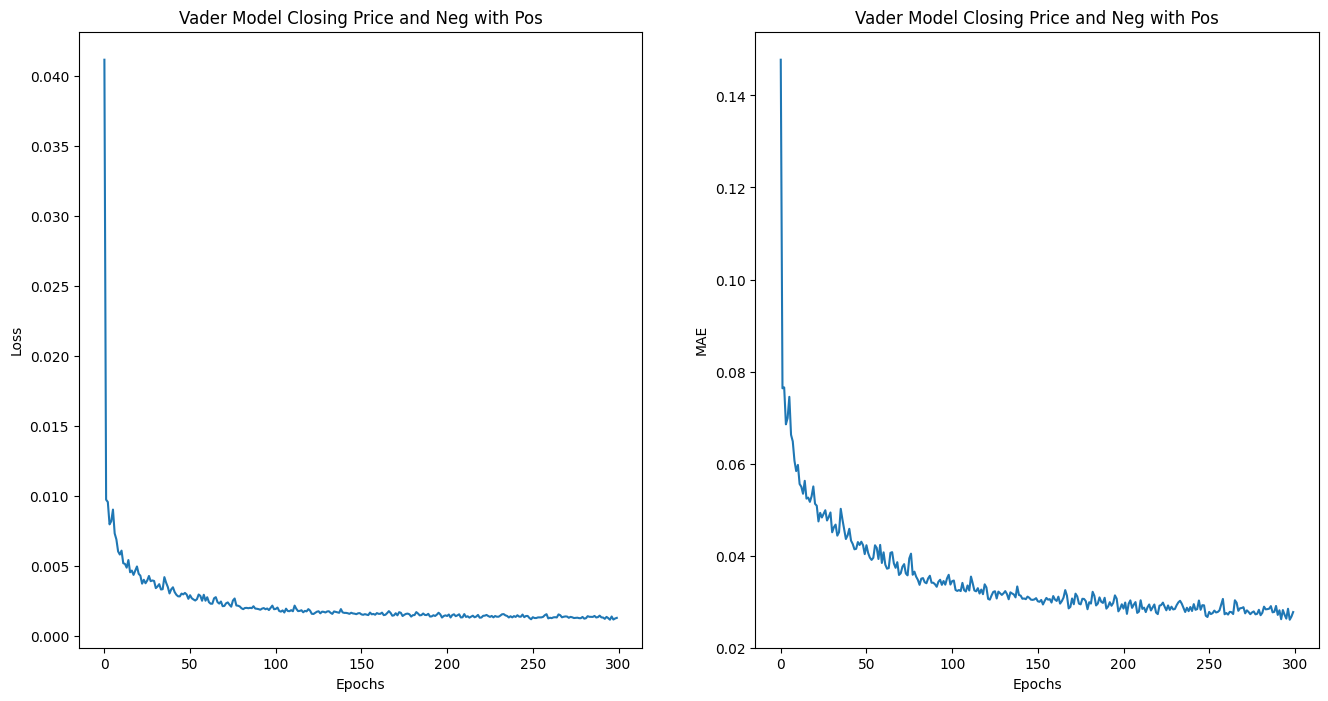

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history2.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and Neg with Pos")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history2.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price and Neg with Pos")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model2.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 2))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


In [ ]:
rmse2 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse2)

8.271489796971943


<ipython-input-51-f774b729858d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['Date'] = dates[:amzn_comp_len]
<ipython-input-51-f774b729858d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing2['Date'] = dates[amzn_comp_len:]
<ipython-input-51-f774b729858d>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

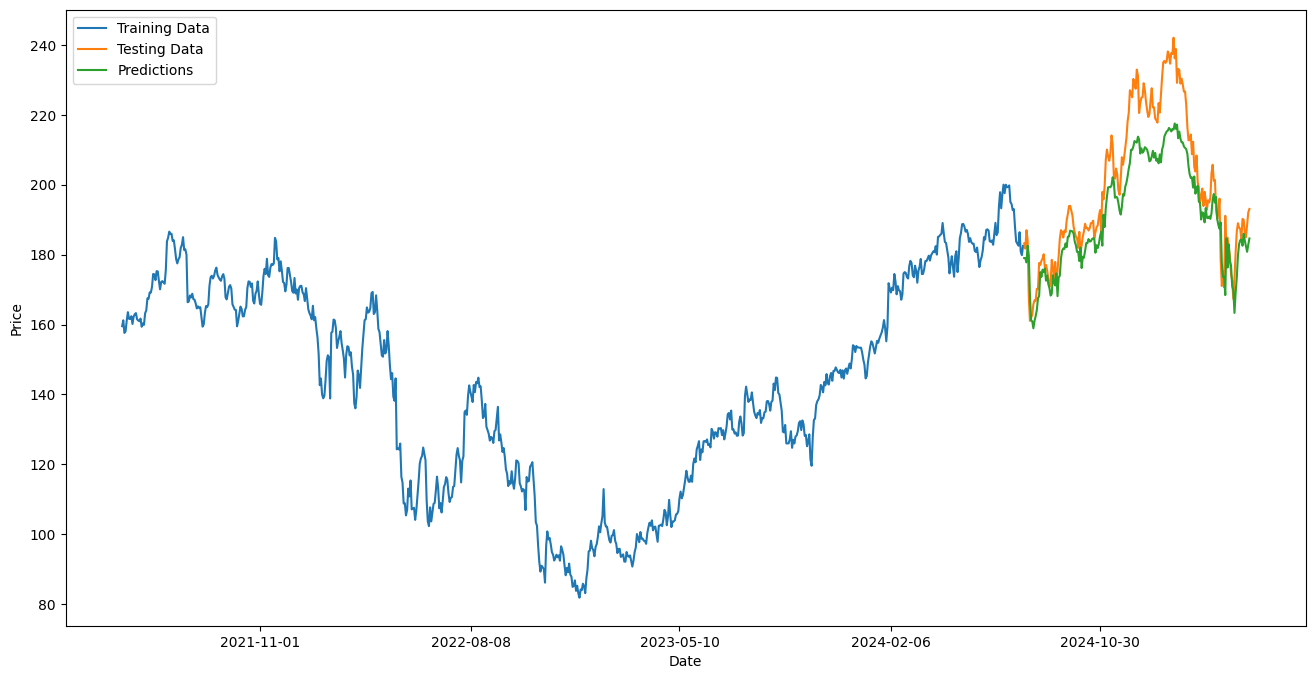

In [ ]:
train2 = amzn_adj_and_compound[:amzn_comp_len]
train2['Date'] = dates[:amzn_comp_len]
testing2 = amzn_adj_and_compound[amzn_comp_len:]
testing2['Date'] = dates[amzn_comp_len:]
testing2['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train2['Date'],train2['Close'], label = "Training Data")
plt.plot(testing2['Date'],testing2['Close'], label = "Testing Data")
plt.plot(testing2['Date'], testing2['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing2.head()

,Close,compound,Date,Predictions
785,183.199997,0.9481,2024-07-29,179.020168
786,181.710007,-0.3612,2024-07-30,178.976706
787,186.979996,0.9911,2024-07-31,177.768344
788,184.070007,0.6482,2024-08-01,182.553850
789,167.899994,0.8316,2024-08-02,179.872705


# **Model 3 Closing and Sentiment Scores**

In [ ]:
amzn_data = data[['Close','neg','neu','pos','compound']]
amzn_data.head()

,Close,neg,neu,pos,compound
0,159.524506,0.000,0.923,0.077,0.8850
1,161.195496,0.067,0.889,0.044,-0.7430
2,157.597000,0.065,0.829,0.106,0.8449
3,158.073502,0.017,0.855,0.128,0.9501
4,161.145004,0.014,0.914,0.072,0.9008


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[ 1.59524506e+02  0.00000000e+00  9.23000000e-01  7.70000000e-02
   8.85000000e-01]
 [ 1.61195496e+02  6.70000000e-02  8.89000000e-01  4.40000000e-02
  -7.43000000e-01]
 [ 1.57597000e+02  6.50000000e-02  8.29000000e-01  1.06000000e-01
   8.44900000e-01]
 ...
 [ 1.88710007e+02  3.60000000e-02  9.31000000e-01  3.30000000e-02
  -2.73200000e-01]
 [ 1.92080002e+02  2.00000000e-02  9.02000000e-01  7.80000000e-02
   8.42200000e-01]
 [ 1.93059998e+02  8.10000000e-02  8.85000000e-01  3.50000000e-02
  -9.24600000e-01]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[ 1.59524506e+02  0.00000000e+00  9.23000000e-01  7.70000000e-02
   8.85000000e-01]
 [ 1.61195496e+02  6.70000000e-02  8.89000000e-01  4.40000000e-02
  -7.43000000e-01]
 [ 1.57597000e+02  6.50000000e-02  8.29000000e-01  1.06000000e-01
   8.44900000e-01]
 ...
 [ 1.80830002e+02  3.70000000e-02  8.91000000e-01  7.20000000e-02
   7.84500000e-01]
 [ 1.79850006e+02  3.90000000e-02  9.01000000e-01  6.00000000e-02
   3.81800000e-01]
 [ 1.82500000e+02  7.00000000e-03  9.36000000e-01  5.70000000e-02
   8.88500000e-01]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956 -1.          0.64351852 -0.60512821  0.88567694]
 [ 0.34329829 -0.47859922  0.48611111 -0.77435897 -0.75124428]
 [ 0.28239973 -0.49416342  0.20833333 -0.45641026  0.8453572 ]
 ...
 [ 0.67557966 -0.71206226  0.49537037 -0.63076923  0.78462621]
 [ 0.65899486 -0.69649805  0.54166667 -0.69230769  0.37971947]
 [ 0.7038416  -0.94552529  0.7037037  -0.70769231  0.88919612]]


(785, 5)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 5)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 5)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (227, 5)
Test inputs with a reshape : (227, 5)
Test inputs after transformed : (227, 5)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 30 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(755, 30, 5)
(755, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],5))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(755, 30, 5)
755
30


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],5))
print(X_test.shape)

(197, 30, 5)
(197, 30, 5)


In [ ]:
model3 = Sequential()
model3.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 5), activation='tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units = 100, activation='tanh'))
model3.add(Dropout(0.2))
model3.add(Dense(units=1))
model3.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model3.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 30, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 30, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 30, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,701 (1.08 MB)

 Trainable params: 283,701 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history3 = model3.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1088 - mae: 0.2504
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0321 - mae: 0.1407
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0272 - mae: 0.1314
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0202 - mae: 0.1123
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0193 - mae: 0.1091
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0177 - mae: 0.1035
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0159 - mae: 0.0977
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0135 - mae: 0.0881
Epoch 9/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0152 - mae: 0.0969
Epoch 10/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0136 - mae: 0.0894
Epoch 11/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0128 - mae: 0.0879
Epoch 12/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0120 - mae: 0.0855
Epoch 13/300
24/24 ━━━━━━

Text(0, 0.5, 'MAE')

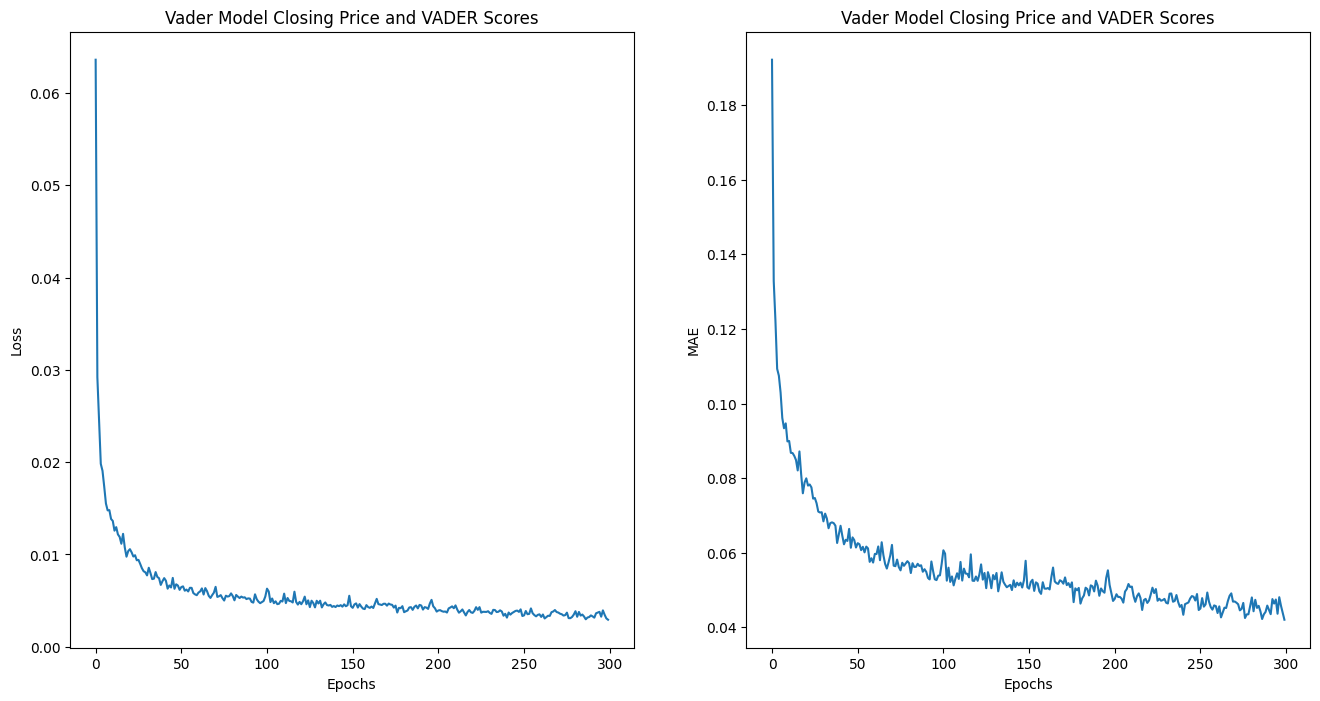

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history3.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and VADER Scores")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history3.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price and VADER Scores")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model3.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 4))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
rmse3 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse3)

9.93043969508079


<ipython-input-91-1d5cd43c47de>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train3['Date'] = dates[:amzn_comp_len]
<ipython-input-91-1d5cd43c47de>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing3['Date'] = dates[amzn_comp_len:]
<ipython-input-91-1d5cd43c47de>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

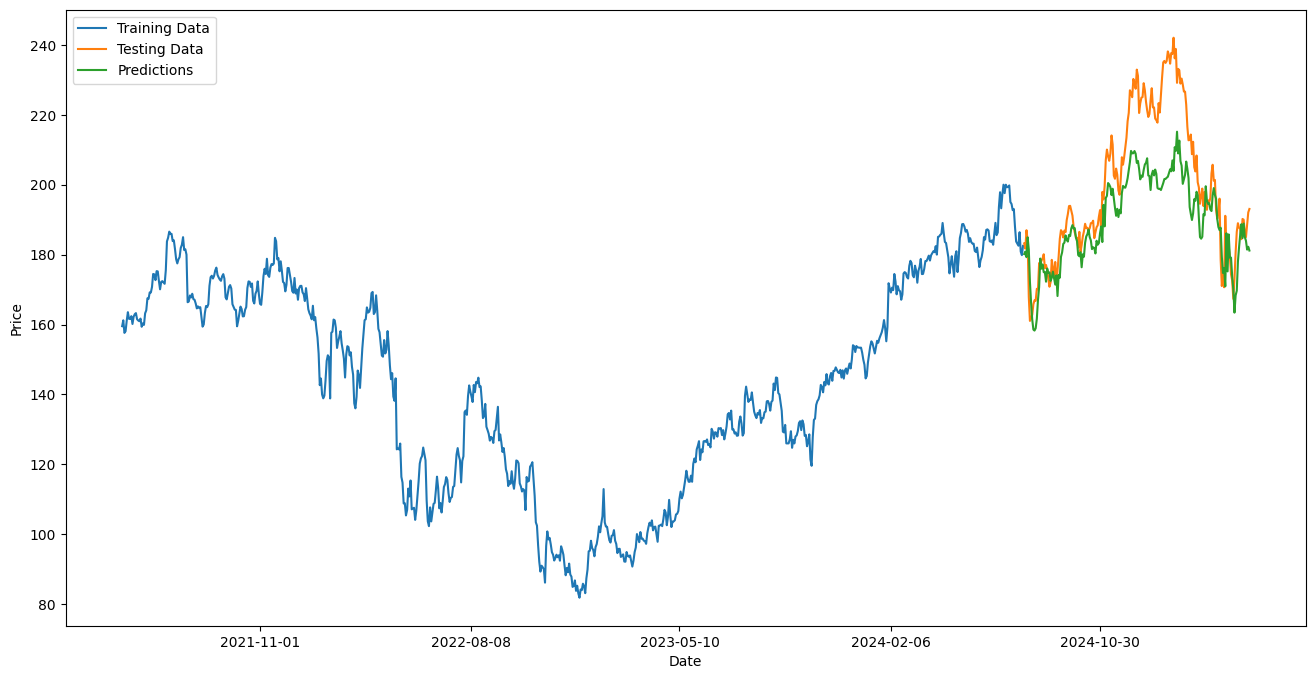

In [ ]:
train3 = amzn_data[:amzn_comp_len]
train3['Date'] = dates[:amzn_comp_len]
testing3 = amzn_data[amzn_comp_len:]
testing3['Date'] = dates[amzn_comp_len:]
testing3['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train3['Date'],train3['Close'], label = "Training Data")
plt.plot(testing3['Date'],testing3['Close'], label = "Testing Data")
plt.plot(testing3['Date'], testing3['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# **Model 4 with all the data fed to the model**  

In [ ]:
amzn_data = data[['Close','Open','High','Low','neg','neu','pos','compound']]
amzn_data.head()

,Close,Open,High,Low,neg,neu,pos,compound
0,159.524506,164.115997,164.149994,159.500000,0.000,0.923,0.077,0.8850
1,161.195496,156.813995,161.899994,156.368500,0.067,0.889,0.044,-0.7430
2,157.597000,159.250000,160.397003,156.654999,0.065,0.829,0.106,0.8449
3,158.073502,159.273499,160.192001,156.649994,0.017,0.855,0.128,0.9501
4,161.145004,159.278000,161.442993,159.149994,0.014,0.914,0.072,0.9008


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[ 1.59524506e+02  1.64115997e+02  1.64149994e+02 ...  9.23000000e-01
   7.70000000e-02  8.85000000e-01]
 [ 1.61195496e+02  1.56813995e+02  1.61899994e+02 ...  8.89000000e-01
   4.40000000e-02 -7.43000000e-01]
 [ 1.57597000e+02  1.59250000e+02  1.60397003e+02 ...  8.29000000e-01
   1.06000000e-01  8.44900000e-01]
 ...
 [ 1.88710007e+02  1.85559998e+02  1.90990005e+02 ...  9.31000000e-01
   3.30000000e-02 -2.73200000e-01]
 [ 1.92080002e+02  1.91429993e+02  1.94330002e+02 ...  9.02000000e-01
   7.80000000e-02  8.42200000e-01]
 [ 1.93059998e+02  1.93380005e+02  1.94690002e+02 ...  8.85000000e-01
   3.50000000e-02 -9.24600000e-01]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[ 1.59524506e+02  1.64115997e+02  1.64149994e+02 ...  9.23000000e-01
   7.70000000e-02  8.85000000e-01]
 [ 1.61195496e+02  1.56813995e+02  1.61899994e+02 ...  8.89000000e-01
   4.40000000e-02 -7.43000000e-01]
 [ 1.57597000e+02  1.59250000e+02  1.60397003e+02 ...  8.29000000e-01
   1.06000000e-01  8.44900000e-01]
 ...
 [ 1.80830002e+02  1.83199997e+02  1.85449997e+02 ...  8.91000000e-01
   7.20000000e-02  7.84500000e-01]
 [ 1.79850006e+02  1.82910004e+02  1.83899994e+02 ...  9.01000000e-01
   6.00000000e-02  3.81800000e-01]
 [ 1.82500000e+02  1.80389999e+02  1.83190002e+02 ...  9.36000000e-01
   5.70000000e-02  8.88500000e-01]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956  0.38658025  0.37054018 ...  0.64351852 -0.60512821
   0.88567694]
 [ 0.34329829  0.26206832  0.33231388 ...  0.48611111 -0.77435897
  -0.75124428]
 [ 0.28239973  0.30360647  0.30677887 ...  0.20833333 -0.45641026
   0.8453572 ]
 ...
 [ 0.67557966  0.7119959   0.73241589 ...  0.49537037 -0.63076923
   0.78462621]
 [ 0.65899486  0.70705101  0.70608216 ...  0.54166667 -0.69230769
   0.37971947]
 [ 0.7038416   0.66408052  0.69401978 ...  0.7037037  -0.70769231
   0.88919612]]


(785, 8)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 8)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 8)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (227, 8)
Test inputs with a reshape : (227, 8)
Test inputs after transformed : (227, 8)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))


These values are smaller than the 30 day minimum
<class 'list'>
<class 'list'>


In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(755, 30, 8)
(755, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],8))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(755, 30, 8)
755
30


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],8))
print(X_test.shape)

(197, 30, 8)
(197, 30, 8)


In [ ]:
model4 = Sequential()
model4.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 8), activation='tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units = 100, activation='tanh'))
model4.add(Dropout(0.2))
model4.add(Dense(units=1))
model4.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model4.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 30, 100)        │        43,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 30, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 30, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284,901 (1.09 MB)

 Trainable params: 284,901 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history4 = model4.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0971 - mae: 0.2373
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0307 - mae: 0.1382
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0243 - mae: 0.1242
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0202 - mae: 0.1119
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0171 - mae: 0.1036
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0161 - mae: 0.0999
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0144 - mae: 0.0938
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0142 - mae: 0.0923
Epoch 9/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0132 - mae: 0.0886
Epoch 10/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0122 - mae: 0.0864
Epoch 11/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0129 - mae: 0.0901
Epoch 12/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0120 - mae: 0.0876
Epoch 13/300
24/24 ━━━━━━

Text(0, 0.5, 'MAE')

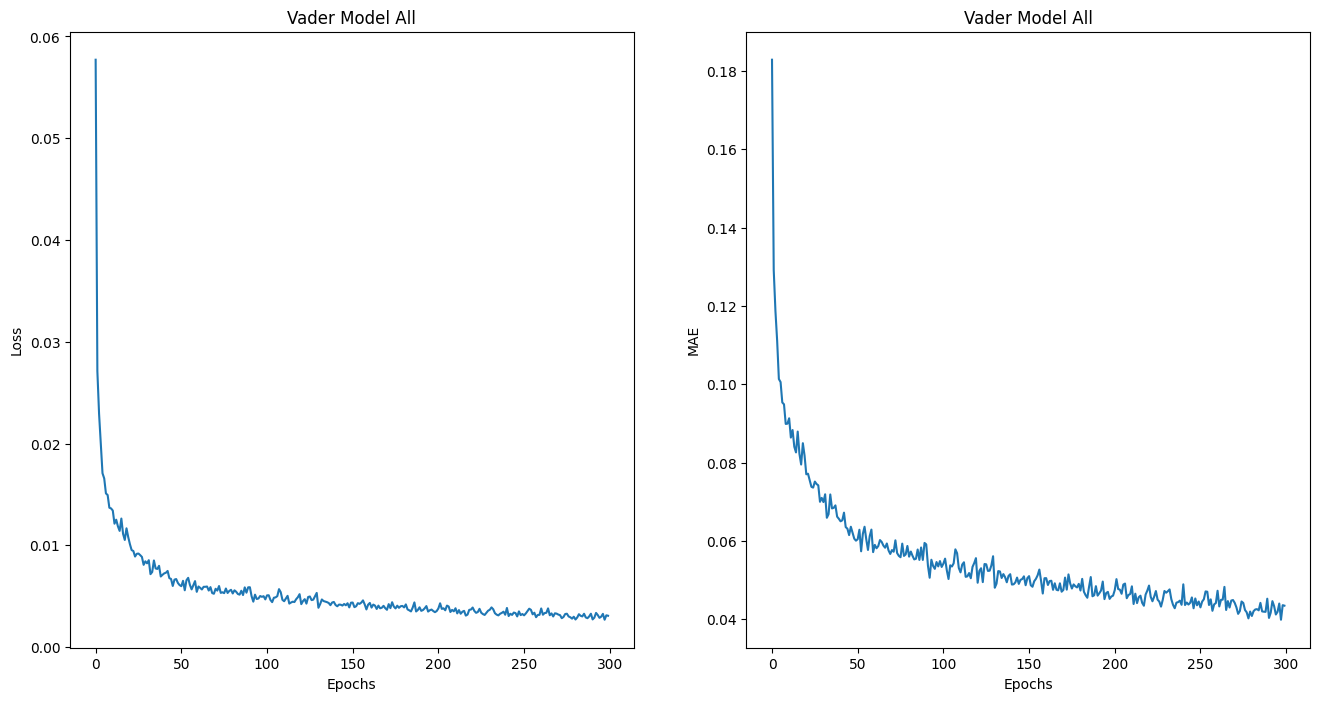

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history4.history['loss'], label = 'Training Loss')
plt.title("Vader Model All")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history4.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model All")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model4.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 7))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
rmse4 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse4)

10.948775268141732


<ipython-input-109-9edb5046622c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train4['Date'] = dates[:amzn_comp_len]
<ipython-input-109-9edb5046622c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing4['Date'] = dates[amzn_comp_len:]
<ipython-input-109-9edb5046622c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

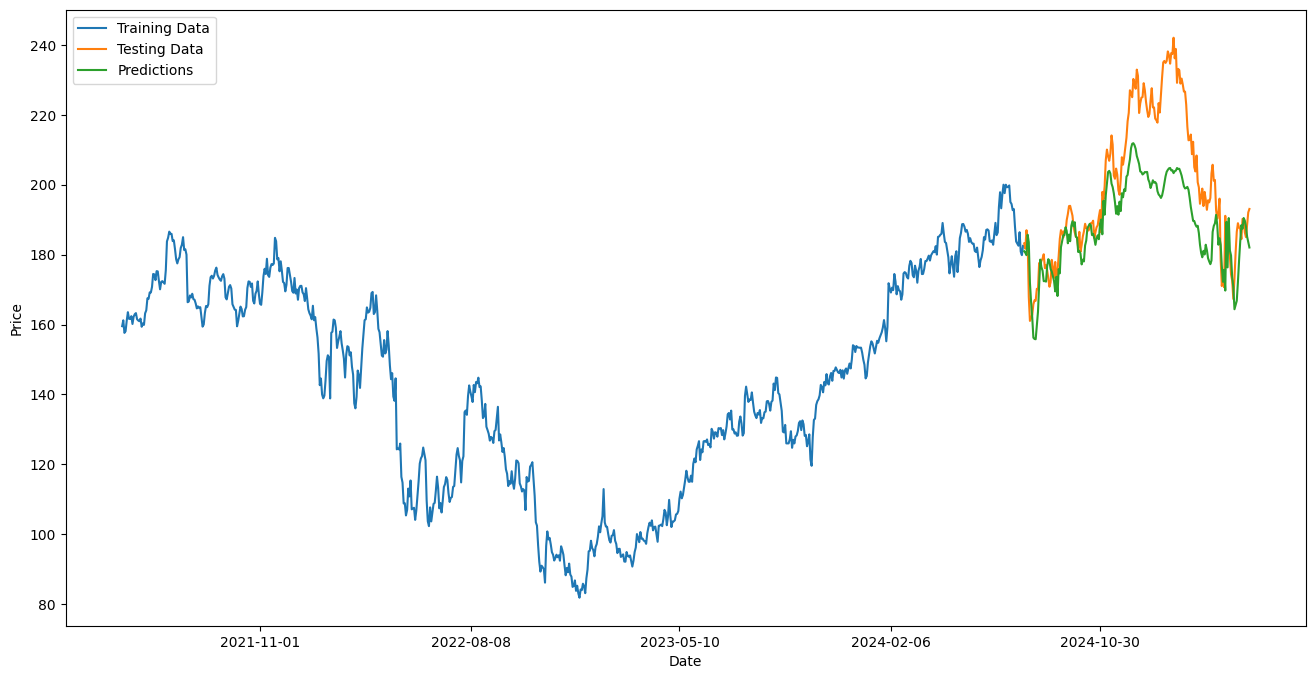

In [ ]:
train4 = amzn_data[:amzn_comp_len]
train4['Date'] = dates[:amzn_comp_len]
testing4 = amzn_data[amzn_comp_len:]
testing4['Date'] = dates[amzn_comp_len:]
testing4['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train4['Date'],train4['Close'], label = "Training Data")
plt.plot(testing4['Date'],testing4['Close'], label = "Testing Data")
plt.plot(testing4['Date'], testing4['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing4.head()

,Close,Open,High,Low,neg,neu,pos,compound,Date,Predictions
785,183.199997,183.839996,184.750000,182.380005,0.006,0.948,0.046,0.9481,2024-07-29,180.962082
786,181.710007,184.720001,185.860001,179.380005,0.049,0.913,0.038,-0.3612,2024-07-30,180.518869
787,186.979996,185.050003,187.940002,184.460007,0.043,0.805,0.152,0.9911,2024-07-31,179.834083
788,184.070007,189.289993,190.600006,181.869995,0.052,0.896,0.052,0.6482,2024-08-01,185.679215
789,167.899994,166.750000,168.770004,160.550003,0.054,0.874,0.072,0.8316,2024-08-02,183.536964


In [ ]:
!pip install joblib

In [ ]:
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models"
os.chdir(PROJECT_FOLDER)
print(os.getcwd())

/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models


In [ ]:
import joblib
joblib.dump(model1,'VADER_30Day_Model1')
joblib.dump(model2,'VADER_30Day_Model2')
joblib.dump(model3,'VADER_30Day_Model3')
joblib.dump(model4,'VADER_30Day_Model4')

['VADER_30Day_Model4']

# **Comparison Between**

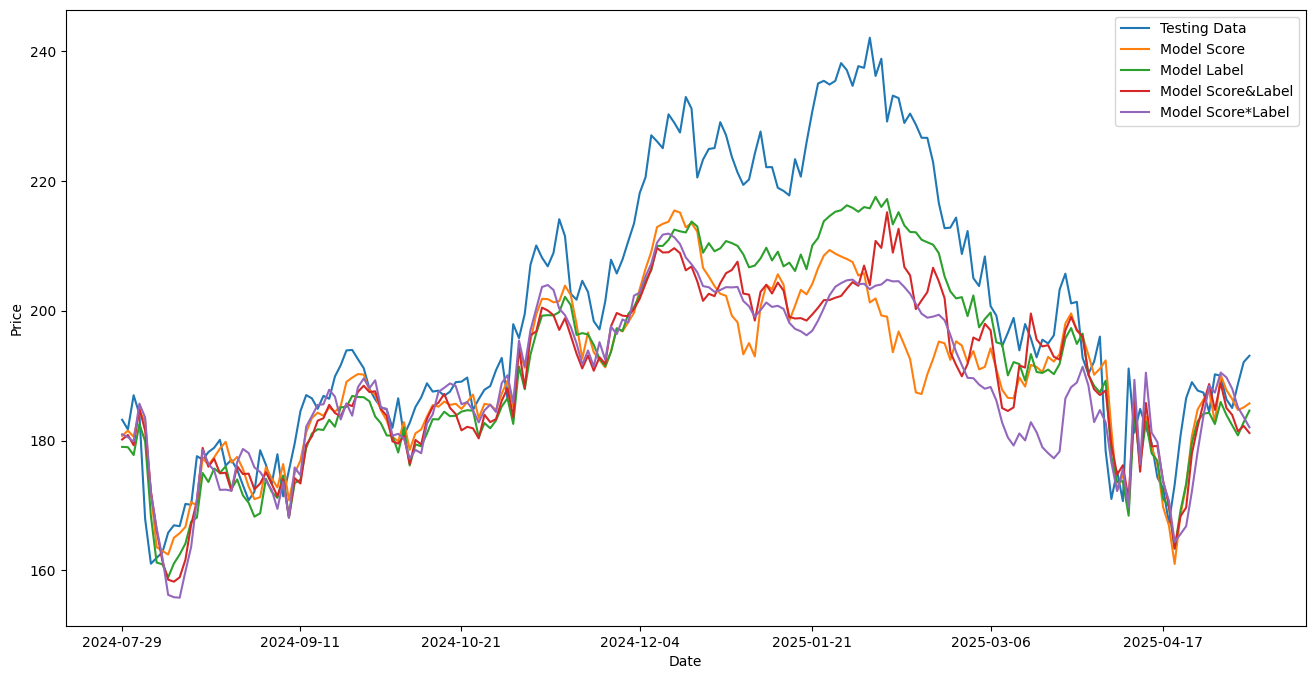

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(testing['Date'],testing['Close'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Model Score")

plt.plot(testing2['Date'],testing2['Predictions'], label = "Model Label")
plt.plot(testing3['Date'],testing3['Predictions'], label = "Model Score&Label")
plt.plot(testing4['Date'], testing4['Predictions'], label ="Model Score*Label")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()